<a href="https://colab.research.google.com/github/Sirichandana845/NLP/blob/main/2403a52280_NLP_Assignment_10_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.9 MB/s eta 0:00:00


In [2]:
# ================================
# Loading Pre-trained Embeddings
# ================================
from gensim.models import KeyedVectors
import gensim.downloader as api

# ================================
# Handling Matrices & Numerical Operations
# ================================
import numpy as np

# ================================
# Visualization
# ================================
import matplotlib.pyplot as plt

# ================================
# t-SNE for Dimensionality Reduction
# ================================
from sklearn.manifold import TSNE

In [3]:
# Load pre-trained Word2Vec model (may take time on first download)
model_word2vec = api.load("word2vec-google-news-300")
model_glove = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
[==================================================] 100.0% 128.1/128.1MB downloaded


In [11]:
word_list = [

    # Space & Astronomy
    "planet", "star", "galaxy", "comet", "astronaut",

    # Sports
    "football", "basketball", "tennis", "cricket", "swimmer",

    # Food & Drinks
    "pizza", "burger", "pasta", "coffee", "tea",

    # Music & Art
    "guitar", "piano", "violin", "painting", "sculpture",

    # Professions
    "engineer", "artist", "scientist", "pilot", "chef",

    # Colors
    "red", "blue", "green", "yellow", "purple",

    # Emotions
    "happy", "sad", "angry", "excited", "calm",

    # Technology (advanced)
    "robot", "algorithm", "blockchain", "cryptography", "neural_network"
]


In [12]:
vectors = [model_word2vec[word] for word in word_list if word in model_word2vec]

# Convert to NumPy array
vectors_word2vec = np.array(vectors)

print("Total selected words:", len(word_list))
print("Vector shape:", vectors_word2vec.shape)
print(vectors_word2vec[0])

Total selected words: 40
Vector shape: (38, 300)
[-0.01550293  0.20703125  0.18554688  0.11523438 -0.2578125   0.19628906
  0.30078125 -0.20898438  0.05395508 -0.0135498  -0.1484375  -0.16308594
  0.13574219 -0.14550781  0.05249023  0.30859375 -0.08300781  0.09667969
  0.08007812  0.30273438 -0.05908203 -0.01379395  0.13964844 -0.31054688
  0.1953125  -0.01135254 -0.09228516  0.09130859  0.171875   -0.20800781
 -0.02868652 -0.16601562 -0.14550781  0.14257812 -0.06103516  0.15625
  0.0135498  -0.18066406  0.19238281  0.09521484 -0.10595703  0.08544922
 -0.00765991  0.41796875  0.2578125   0.03442383  0.29492188  0.14746094
 -0.04541016 -0.01806641 -0.10400391  0.0022583  -0.00588989 -0.13867188
 -0.04589844  0.00891113  0.16601562 -0.15820312  0.00787354  0.13867188
  0.02856445  0.10107422  0.03015137 -0.06738281 -0.18945312 -0.09423828
 -0.00292969 -0.03344727 -0.203125    0.11035156 -0.19824219 -0.17382812
  0.02856445  0.08642578 -0.19238281 -0.33984375  0.09228516  0.09179688
 -0.3

In [13]:
vectors = [model_glove[word] for word in word_list if word in model_glove]

# Convert to NumPy array
vectors_glove = np.array(vectors)

print("Total selected words:", len(word_list))
print("Vector shape:", vectors_glove.shape)
print(vectors_glove[0])

Total selected words: 40
Vector shape: (38, 100)
[-0.32489   0.11055   1.4551    0.38167   0.099116 -0.14963   0.3576
 -0.11741   0.40503  -0.025728  0.21315  -0.18059   0.38213  -0.78319
  0.13713  -0.90874   0.80196   0.45898   0.24095   0.53645   0.35761
  0.047395 -0.93401  -0.32704   0.79418   0.84616   0.51435   0.40484
  0.19639   0.13443   0.40279  -0.055496  0.01075   0.3946    0.58176
  0.36711  -0.10515  -0.019983 -0.22179  -0.55157  -1.0581    0.40838
 -0.44049   0.24088  -0.31195   0.91806  -0.4839    0.73394   0.003651
  0.38094   0.40537   0.16947   0.023389  0.78114   0.14648  -1.9375
  0.24337   0.55162   1.0125    0.60651  -0.38828   1.3318   -0.35234
 -0.1913    1.4103    0.64803  -0.19678  -0.16569   0.58804  -0.25316
  0.47589  -0.27119   0.14236   0.46197  -0.67993  -0.73906   0.23265
 -0.79162  -0.3612    0.8504   -0.13135   0.82447  -0.85928   0.29078
 -0.13424   0.27077   0.65423  -0.5059    0.25287   0.082399  0.36619
  0.29176   0.96145   0.15916  -0.088952 -

In [14]:
# Assume vectors already extracted from previous step
# vectors shape example: (40, 100)

# Apply t-SNE
tsne = TSNE(
    n_components=2,      # Reduce to 2D
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_word2vec)

# Store results
print("Original Shape:", vectors_word2vec.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Display first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Display first 5 coordinates of word2vec
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_word2vec[:5])

Original Shape: (38, 300)
Reduced Shape: (38, 2)

First 5 t-SNE Coordinates:
[[ -40.85256 -142.72028]
 [  64.99496 -217.94164]
 [ 260.66635  270.89462]
 [ 326.67114  313.86438]
 [-210.65259 -308.41037]]

First 5 t-SNE Coordinates:
[[-0.01550293  0.20703125  0.18554688 ...  0.01623535  0.27539062
   0.00527954]
 [ 0.1640625   0.18847656  0.14160156 ... -0.07128906 -0.10205078
   0.01446533]
 [ 0.08496094  0.4140625   0.06225586 ...  0.02807617 -0.02636719
   0.04248047]
 [-0.15625     0.25976562  0.06884766 ... -0.29101562  0.32421875
  -0.33203125]
 [-0.08300781 -0.06152344 -0.3046875  ...  0.01489258 -0.01672363
  -0.31445312]]


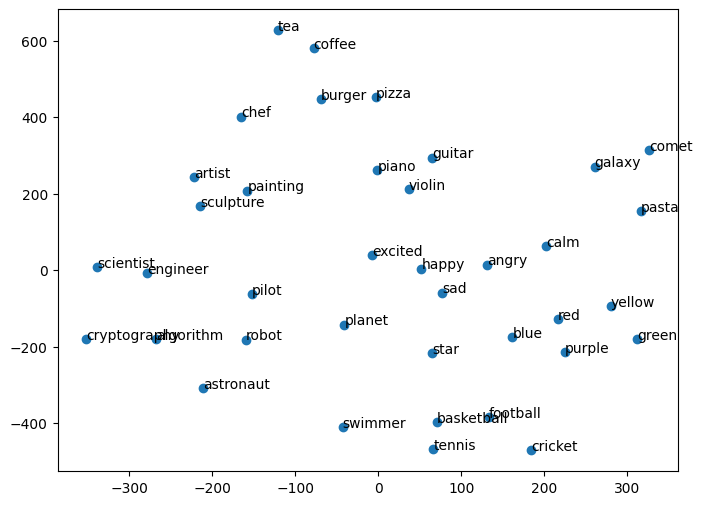

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1])

# Create a filtered word list that matches the length and order of tsne_coordinates
filtered_word_list = [word for word in word_list if word in model_word2vec]

for i, word in enumerate(filtered_word_list):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()

In [18]:
# Assume vectors already extracted from previous step
# vectors shape example: (40, 100)

# Apply t-SNE
tsne = TSNE(
    n_components=2,      # Reduce to 2D
    random_state=42,
    perplexity=10,
    learning_rate=200
)

tsne_coordinates = tsne.fit_transform(vectors_glove)

# Store results
print("Original Shape:", vectors_glove.shape)
print("Reduced Shape:", tsne_coordinates.shape)

# Display first 5 coordinates
print("\nFirst 5 t-SNE Coordinates:")
print(tsne_coordinates[:5])
# Display first 5 coordinates of glove
print("\nFirst 5 t-SNE Coordinates:")
print(vectors_glove[:5])

Original Shape: (38, 100)
Reduced Shape: (38, 2)

First 5 t-SNE Coordinates:
[[38.248337 68.188095]
 [54.05521  37.426937]
 [51.869843 57.62728 ]
 [51.643852 78.45428 ]
 [11.566482 38.277233]]

First 5 t-SNE Coordinates:
[[-0.32489    0.11055    1.4551     0.38167    0.099116  -0.14963
   0.3576    -0.11741    0.40503   -0.025728   0.21315   -0.18059
   0.38213   -0.78319    0.13713   -0.90874    0.80196    0.45898
   0.24095    0.53645    0.35761    0.047395  -0.93401   -0.32704
   0.79418    0.84616    0.51435    0.40484    0.19639    0.13443
   0.40279   -0.055496   0.01075    0.3946     0.58176    0.36711
  -0.10515   -0.019983  -0.22179   -0.55157   -1.0581     0.40838
  -0.44049    0.24088   -0.31195    0.91806   -0.4839     0.73394
   0.003651   0.38094    0.40537    0.16947    0.023389   0.78114
   0.14648   -1.9375     0.24337    0.55162    1.0125     0.60651
  -0.38828    1.3318    -0.35234   -0.1913     1.4103     0.64803
  -0.19678   -0.16569    0.58804   -0.25316    0.4758

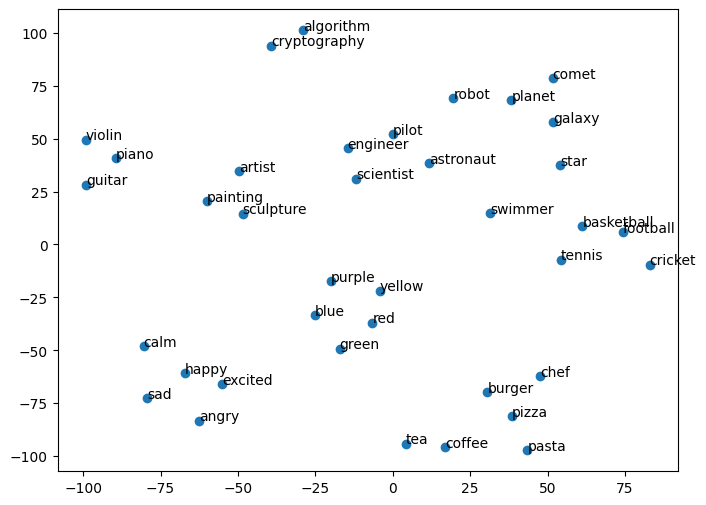

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(tsne_coordinates[:,0], tsne_coordinates[:,1])

# Create a filtered word list that matches the length and order of tsne_coordinates
filtered_word_list_glove = [word for word in word_list if word in model_glove]

for i, word in enumerate(filtered_word_list_glove):
    plt.annotate(word, (tsne_coordinates[i,0], tsne_coordinates[i,1]))

plt.show()